# 6항 COMPOSITE Rule — 단일 full-6 PSO (선별 없이)

`composite_rule.ipynb` 와 **동일한** 목적함수·평가기·CRN 을 그대로 재사용하되,
항 선별(Stage 0 단일 grid / Stage 1 Shapley·argmin)을 **전부 생략**하고
선정한 6개 항 전부를 simplex 위에서 선형결합하여 **한 번의 PSO** 로 $w^*$ 를 구한다.

$$\pi(j) = \sum_t w_t \cdot \widetilde{term}_t(j), \qquad \sum_t w_t = 1$$

**목적함수** (정규화 ON):
$$\hat{J}(w) = \frac{1}{N}\sum_i \left[ \frac{Mk_i}{\text{mk\_ref}} + \frac{AQT_i}{\text{qv\_ref}} \right], \quad AQT = \frac{QV_{\text{total}}}{N_{\text{jobs}}}$$

**검증 (Stage 3)**: Holm-Bonferroni baseline paired t-test + SAA in/out bias.
- t-test 는 COMPOSITE 를 6개 baseline 과 **동시 비교**하므로 다중비교 보정(Holm) 적용.
- SAA bias 는 단일 held-out 평가라 보정 없음.

**병렬 / AWS 분리 실행**
- `N_JOBS` 로 PSO 입자 평가를 프로세스 병렬화 (AWS 다코어에서 가속).
- AWS 에서 PSO 만 돌려 `full6_pso_state.json` 을 받아오면, 로컬에서 `RUN_PSO=False`
  로 두고 그 $w^*$ 로 검증(Stage 3)만 이어서 수행할 수 있다.

## 1. 환경 설정 및 데이터 로드

In [1]:
import os
import sys
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from dotenv import load_dotenv
from scipy import stats

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

load_dotenv(os.path.join(PROJECT_ROOT, '.env'), override=True)

from utils import DataLoader
from tuning.saa_evaluator import SAAEvaluator, TRANSITION_RISK_CACHE_PATH
from tuning.composite_rule import (
    load_normalization_ref,
    DynamicCompositeEvaluator,
    pso_simplex,
)

# 한글 폰트: 실제 설치된 것만 적용 → 미설치 폰트 findfont 경고 방지
_installed_fonts = {f.name for f in fm.fontManager.ttflist}
plt.rcParams['font.family'] = [f for f in ['Noto Sans KR', 'Malgun Gothic'] if f in _installed_fonts] + ['sans-serif']
plt.rcParams['axes.unicode_minus'] = False

BASE_DATA_PATH = os.path.join(PROJECT_ROOT, 'data')
data = DataLoader(BASE_DATA_PATH).load_all_data()
print(f"Jobs: {len(data['jobs'])} / Operations: {len(data['operations'])} / Machines: {len(data['machines'])}")

Jobs: 60 / Operations: 870 / Machines: 60


## 2. 정규화 기준 로드 + transition risk 캐시 준비

- `mk_ref`, `qv_ref` ← `data/normalization_ref.json`
- transition risk 캐시가 없으면 `SAAEvaluator` 1회 초기화로 생성 (deterministic, 시뮬 없음).

In [2]:
DOWN_ACTIVE = True
PM_ACTIVE = False
BASE_SEED = 0

NORM_REF_PATH = os.path.join(PROJECT_ROOT, 'data', 'normalization_ref.json')
MK_REF, QV_REF_AQT, NORM_RAW = load_normalization_ref(NORM_REF_PATH)
print(f"mk_ref         = {MK_REF:.3f}")
print(f"qv_ref (total) = {NORM_RAW['qv_ref']:.3f}")
print(f"qv_ref (AQT)   = {QV_REF_AQT:.3f}  (= qv_ref_total / n_jobs={NORM_RAW.get('n_jobs')})")

if not os.path.exists(TRANSITION_RISK_CACHE_PATH):
    print("\n[init] transition_risk 캐시 없음 → SAAEvaluator 1회 초기화로 생성")
    _init = SAAEvaluator(
        data, obj_weights=(1.0, 1.0), base_seed=BASE_SEED,
        down_active=DOWN_ACTIVE, pm_active=PM_ACTIVE,
        mk_ref=MK_REF, qv_ref=QV_REF_AQT,
    )
    print(f"[init] 생성 완료 -> {TRANSITION_RISK_CACHE_PATH}")
else:
    print(f"[skip] transition_risk 캐시 존재: {TRANSITION_RISK_CACHE_PATH}")

evaluator = DynamicCompositeEvaluator(
    data, mk_ref=MK_REF, qv_ref_aqt=QV_REF_AQT,
    base_seed=BASE_SEED, down_active=DOWN_ACTIVE, pm_active=PM_ACTIVE,
)
print("\n[evaluator]", evaluator.summary())

mk_ref         = 14734.158
qv_ref (total) = 68400.286
qv_ref (AQT)   = 1140.005  (= qv_ref_total / n_jobs=60)
[skip] transition_risk 캐시 존재: c:\Users\hun99\Desktop\박성현\숭실대학교\26년 4학년 1학기\전공종합논문설계\simulation_teamwork\tuning\transition_risk.json

[evaluator] {'mk_ref': 14734.157948534785, 'qv_ref_aqt': 1140.0047639331883, 'obj_weights': (1.0, 1.0), 'n_jobs': 60, 'down_active': True, 'pm_active': False, 'transition_risk_size': 3}


## 3. 설정

- `PSO_KWARGS` : swarm / n_iter 여기서 변경 (기본 12 / 20).
- `N_JOBS` : PSO 입자 평가 병렬도. 한 iteration 의 swarm 입자는 서로 독립이라 병렬 가능.
  - `1` = 순차 (로컬/재현). `swarm_size` = 한 iteration 을 1 wave 로 (권장, AWS).
  - `-1` = 가용 코어 전부. (프로세스 병렬이라 os.environ race 없음)
- `RUN_PSO` : AWS 에서 받아온 `full6_pso_state.json` 으로 검증만 하려면 `False`.

In [3]:
CANDIDATE_TERMS = ['PT', 'SLACK', 'SETUP', 'C_TRANSITION', 'COMPLETION_FAST', 'WAITING']

PSO_KWARGS = dict(swarm_size=24, n_iter=40, seed=42)   # <- swarm / n_iter 여기서 변경
N_JOBS = 3            # <- 병렬도. AWS 면 swarm_size(=한 wave) 또는 -1(전부). 로컬 순차는 1

N_RUNS = 10            # PSO 평가용 SAA replication (CRN)
N_TEST = 30            # baseline t-test replication
N_BIAS = 30            # held-out bias replication
BIAS_SEED_OFFSET = 10_000   # 학습 묶음 [0..N_TEST) 와 안 겹치는 held-out 영역
ALPHA = 0.05
BASELINE_RULES = ['FIFO', 'SPT', 'LPT', 'MIN_QTIME', 'SPTSSU', 'random']

# AWS 결과 load/save: AWS 에서 PSO 돌려 나온 full6_pso_state.json 을 받아왔다면 RUN_PSO=False.
PSO_STATE_PATH = os.path.join(PROJECT_ROOT, 'tuning', 'full6_pso_state.json')
RUN_PSO = True

pso_evals = PSO_KWARGS['swarm_size'] * (PSO_KWARGS['n_iter'] + 1)
print(f"후보 항 ({len(CANDIDATE_TERMS)}): {CANDIDATE_TERMS}")
print(f"PSO={PSO_KWARGS}  N_JOBS={N_JOBS}  RUN_PSO={RUN_PSO}")
print(f"-> eval {pso_evals} 회 x N_RUNS={N_RUNS} = {pso_evals*N_RUNS:,} sim")

후보 항 (6): ['PT', 'SLACK', 'SETUP', 'C_TRANSITION', 'COMPLETION_FAST', 'WAITING']
PSO={'swarm_size': 24, 'n_iter': 40, 'seed': 42}  N_JOBS=3  RUN_PSO=True
-> eval 984 회 x N_RUNS=10 = 9,840 sim


## 4. full-6 PSO → $w^*$  (또는 AWS 결과 로드)

`RUN_PSO=True` 면 6항 전부를 simplex 위에서 한 번의 PSO 로 최적화하고 결과를
`full6_pso_state.json` 에 저장한다. **AWS 에서 이 셀을 돌리면** 그 파일을 로컬로
복사한 뒤 로컬 노트북에서 `RUN_PSO=False` 로 두면 같은 $w^*$ 로 검증을 이어서 한다.

In [4]:
def _eval(w):
    return evaluator.evaluate(CANDIDATE_TERMS, w.tolist(), n_runs=N_RUNS)['J_hat']

if RUN_PSO:
    t0 = time.time()
    pso_out = pso_simplex(_eval, dim=len(CANDIDATE_TERMS), n_jobs=N_JOBS, **PSO_KWARGS, verbose=True)
    elapsed = time.time() - t0
    W_STAR = np.asarray(pso_out['w*'], dtype=float)
    J_STAR = float(pso_out['J*'])
    print(f"\nfull-6 PSO 소요: {elapsed:.1f}s  (n_jobs={N_JOBS})")

    # 상태 저장 — AWS 에서 돌렸으면 이 파일을 로컬로 복사해 RUN_PSO=False 로 재현
    with open(PSO_STATE_PATH, 'w', encoding='utf-8') as f:
        json.dump({
            'candidate_terms': CANDIDATE_TERMS,
            'w_star': {t: float(v) for t, v in zip(CANDIDATE_TERMS, W_STAR)},
            'J_in_sample': J_STAR,
            'pso': dict(PSO_KWARGS),
            'n_runs': N_RUNS,
            'history': [[int(it), float(j)] for it, j in pso_out['history']],
        }, f, ensure_ascii=False, indent=2)
    print(f"PSO 상태 저장: {PSO_STATE_PATH}")
else:
    with open(PSO_STATE_PATH, 'r', encoding='utf-8') as f:
        _st = json.load(f)
    if _st['candidate_terms'] != CANDIDATE_TERMS:
        raise ValueError(f"항 불일치: 파일={_st['candidate_terms']} vs 노트북={CANDIDATE_TERMS}")
    W_STAR = np.array([_st['w_star'][t] for t in CANDIDATE_TERMS], dtype=float)
    J_STAR = float(_st['J_in_sample'])
    print(f"[AWS 결과 로드] {PSO_STATE_PATH}")
    print(f"  pso={_st.get('pso')}  N_RUNS={_st.get('n_runs')}")

print(f"w* = {dict(zip(CANDIDATE_TERMS, [round(float(v), 4) for v in W_STAR]))}")
print(f"J* (in-sample) = {J_STAR:.5f}")

    PSO iter 1/40  g*=0.92499
    PSO iter 2/40  g*=0.92499
    PSO iter 3/40  g*=0.92214
    PSO iter 4/40  g*=0.92214
    PSO iter 5/40  g*=0.92214
    PSO iter 6/40  g*=0.92211
    PSO iter 7/40  g*=0.92126
    PSO iter 8/40  g*=0.91499
    PSO iter 9/40  g*=0.91499
    PSO iter 10/40  g*=0.91499
    PSO iter 11/40  g*=0.91499
    PSO iter 12/40  g*=0.91499
    PSO iter 13/40  g*=0.91469
    PSO iter 14/40  g*=0.91469
    PSO iter 15/40  g*=0.91444
    PSO iter 16/40  g*=0.91444
    PSO iter 17/40  g*=0.91444
    PSO iter 18/40  g*=0.91201
    PSO iter 19/40  g*=0.91201
    PSO iter 20/40  g*=0.91201
    PSO iter 21/40  g*=0.91201
    PSO iter 22/40  g*=0.91068
    PSO iter 23/40  g*=0.91068
    PSO iter 24/40  g*=0.90981
    PSO iter 25/40  g*=0.90981
    PSO iter 26/40  g*=0.90981
    PSO iter 27/40  g*=0.90981
    PSO iter 28/40  g*=0.90894
    PSO iter 29/40  g*=0.90894
    PSO iter 30/40  g*=0.90894
    PSO iter 31/40  g*=0.90894
    PSO iter 32/40  g*=0.90894
    PSO iter 33/4

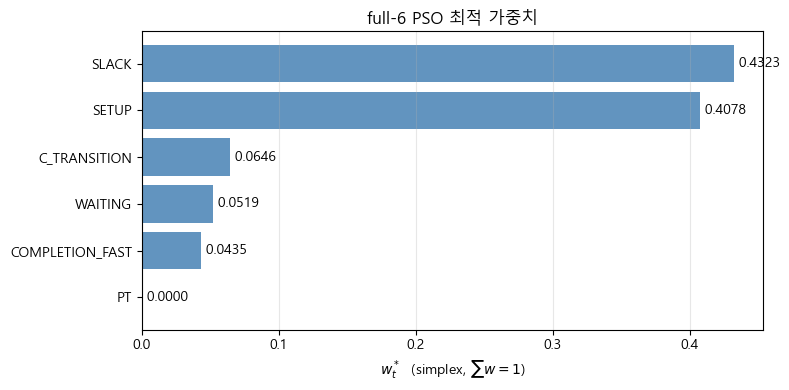

In [5]:
# w* 막대그래프 (가중치 분포 - 0 근처 항은 사실상 미기여)
fig, ax = plt.subplots(figsize=(8, 4))
order = np.argsort(W_STAR)
terms_sorted = [CANDIDATE_TERMS[i] for i in order]
ax.barh(terms_sorted, W_STAR[order], color='steelblue', alpha=0.85)
ax.set_xlabel(r'$w^*_t$  (simplex, $\sum w = 1$)')
ax.set_title('full-6 PSO 최적 가중치')
for y, v in enumerate(W_STAR[order]):
    ax.annotate(f' {v:.4f}', (v, y), va='center')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Stage 3.1 — baseline paired t-test (Holm-Bonferroni)

동일 CRN seed 묶음 N_TEST 회 평가 → COMPOSITE vs 6개 baseline 단측 paired t-test.
6개를 동시 비교하므로 **Holm-Bonferroni step-down** 으로 family-wise error 통제.

In [6]:
t0 = time.time()
J_samples = {}
print(f"[N_TEST={N_TEST} CRN - 동일 seed 묶음으로 모든 rule 평가]")

res_comp = evaluator.evaluate(CANDIDATE_TERMS, W_STAR.tolist(), n_runs=N_TEST)
J_samples['COMPOSITE'] = res_comp['J_samples']
print(f"  COMPOSITE   J={res_comp['J_hat']:.4f} +/- {res_comp['se']:.4f}   elapsed {time.time()-t0:.1f}s")

for rule in BASELINE_RULES:
    res = evaluator.evaluate_rule(rule, n_runs=N_TEST)
    J_samples[rule] = res['J_samples']
    print(f"  {rule:11s} J={res['J_hat']:.4f} +/- {res['se']:.4f}   elapsed {time.time()-t0:.1f}s")

summary_rows = [{
    'rule': label,
    'J_mean': float(js.mean()),
    'J_se': float(js.std(ddof=1) / np.sqrt(len(js))),
} for label, js in J_samples.items()]
summary_df = pd.DataFrame(summary_rows).sort_values('J_mean').reset_index(drop=True)
print('\n[rule별 J 요약]')
print(summary_df.round(5).to_string(index=False))

[N_TEST=30 CRN - 동일 seed 묶음으로 모든 rule 평가]
  COMPOSITE   J=0.9220 +/- 0.0115   elapsed 28.2s
  FIFO        J=1.4847 +/- 0.0219   elapsed 37.9s
  SPT         J=1.3182 +/- 0.0249   elapsed 62.6s
  LPT         J=1.1208 +/- 0.0131   elapsed 84.4s
  MIN_QTIME   J=0.9646 +/- 0.0141   elapsed 94.4s
  SPTSSU      J=1.6262 +/- 0.0180   elapsed 136.4s
  random      J=1.4330 +/- 0.0220   elapsed 146.7s

[rule별 J 요약]
     rule  J_mean    J_se
COMPOSITE 0.92202 0.01149
MIN_QTIME 0.96464 0.01414
      LPT 1.12077 0.01315
      SPT 1.31818 0.02493
   random 1.43299 0.02203
     FIFO 1.48474 0.02186
   SPTSSU 1.62623 0.01804


In [7]:
# COMPOSITE 가 각 baseline 보다 유의하게 낮은가 (단측, <0 가설) + Holm-Bonferroni
comp = J_samples['COMPOSITE']
rows = []
for rule in BASELINE_RULES:
    diff = comp - J_samples[rule]
    if np.isclose(diff.std(ddof=1), 0.0):
        p_one = 0.0 if diff.mean() < 0 else 1.0
        t_stat = float('nan')
    else:
        t_stat, p_two = stats.ttest_rel(comp, J_samples[rule])
        p_one = p_two / 2 if t_stat < 0 else 1.0 - p_two / 2
    rows.append({
        'baseline': rule,
        'mean_diff (COMP - base)': float(diff.mean()),
        't': float(t_stat) if not np.isnan(t_stat) else None,
        'p_one_sided': float(p_one),
    })
ttest_df = pd.DataFrame(rows).sort_values('p_one_sided').reset_index(drop=True)

# Holm-Bonferroni step-down
m = len(BASELINE_RULES)
ttest_df['holm_threshold'] = [ALPHA / (m - i) for i in range(m)]
rejected, stopped = [], False
for _, row in ttest_df.iterrows():
    if stopped or row['p_one_sided'] > row['holm_threshold']:
        rejected.append(False); stopped = True
    else:
        rejected.append(True)
ttest_df['reject_H0 (COMP<base 유의)'] = rejected

print(f'[Paired t-test  COMPOSITE vs baseline, alpha={ALPHA}, Holm-Bonferroni, m={m}]')
print(ttest_df.round(6).to_string(index=False))
n_sig = int(sum(rejected))
print(f"\n>>> 유의하게 우월: {n_sig}/{m} baseline")

[Paired t-test  COMPOSITE vs baseline, alpha=0.05, Holm-Bonferroni, m=6]
 baseline  mean_diff (COMP - base)          t  p_one_sided  holm_threshold  reject_H0 (COMP<base 유의)
   SPTSSU                -0.704217 -46.124887      0.00000        0.008333                      True
     FIFO                -0.562721 -31.654641      0.00000        0.010000                      True
   random                -0.510977 -26.420371      0.00000        0.012500                      True
      LPT                -0.198759 -20.498936      0.00000        0.016667                      True
      SPT                -0.396164 -18.323657      0.00000        0.025000                      True
MIN_QTIME                -0.042621  -4.684794      0.00003        0.050000                      True

>>> 유의하게 우월: 6/6 baseline


## 6. Stage 3.2 — SAA bias (in-sample vs held-out)

$\hat v_N = \min_w \hat J_N(w)$ 는 진짜 $v^*$ 에 대해 아래로 편향(낙관적).
학습에 안 쓴 held-out seed block 에서 $w^*$ 를 재평가해 편향 크기를 진단한다.
단일 평가이므로 다중비교 보정은 적용하지 않는다.

In [8]:
orig_base = evaluator.base_seed
evaluator.base_seed = orig_base + BIAS_SEED_OFFSET
try:
    res_held = evaluator.evaluate(CANDIDATE_TERMS, W_STAR.tolist(), n_runs=N_BIAS)
finally:
    evaluator.base_seed = orig_base

J_in = J_STAR
J_held = res_held['J_hat']
se_held = res_held['se']
bias_est = J_in - J_held   # 음수 <=> in-sample 낙관적 (이론 부합)

print(f"[In-sample]  J* = {J_in:.5f}   (PSO 결과, N={N_RUNS})")
print(f"[Held-out]   J* = {J_held:.5f} +/- {se_held:.5f}   (N_BIAS={N_BIAS}, offset={BIAS_SEED_OFFSET})")
print(f"[Bias 추정]  J_in - J_held = {bias_est:+.5f}")
if bias_est < -3 * se_held:
    print('  -> 명백한 in-sample optimism (이론 일치). 보고서엔 held-out J 를 함께 보고.')
elif bias_est < 0:
    print('  -> 약한 in-sample optimism (SE 범위 내, 단정 어려움).')
else:
    print('  -> in-sample 이 오히려 높음 (sampling noise / N 부족). N_RUNS 증가 검토.')

ci_lo, ci_hi = J_held - 1.96 * se_held, J_held + 1.96 * se_held
print(f"\nHeld-out 95% CI for J(w*): [{ci_lo:.5f}, {ci_hi:.5f}]")

[In-sample]  J* = 0.90795   (PSO 결과, N=10)
[Held-out]   J* = 0.90871 +/- 0.01151   (N_BIAS=30, offset=10000)
[Bias 추정]  J_in - J_held = -0.00076
  -> 약한 in-sample optimism (SE 범위 내, 단정 어려움).

Held-out 95% CI for J(w*): [0.88616, 0.93127]


## 7. 최종 정리 및 저장

In [9]:
print('=' * 60)
print('full-6 COMPOSITE Rule 최종 결과')
print('=' * 60)
print(f'\n[설정]')
print(f'  후보 항 : {CANDIDATE_TERMS}')
print(f'  PSO     : {PSO_KWARGS}  (N_JOBS={N_JOBS}, RUN_PSO={RUN_PSO})')
print(f'  N_RUNS={N_RUNS}  N_TEST={N_TEST}  N_BIAS={N_BIAS}')
print(f'  mk_ref={MK_REF:.3f}  qv_ref_aqt={QV_REF_AQT:.3f}')
print(f'  DOWN_ACTIVE={DOWN_ACTIVE}  PM_ACTIVE={PM_ACTIVE}')

print(f'\n[w*]')
print('  ' + str(dict(zip(CANDIDATE_TERMS, [round(float(v), 4) for v in W_STAR]))))
print(f'  J_in-sample = {J_in:.5f}')
print(f'  J_held-out  = {J_held:.5f} +/- {se_held:.5f}')
print(f'  bias        = {bias_est:+.5f}')

print(f'\n[baseline 대비 유의성, Holm-Bonferroni]')
print(ttest_df[['baseline', 'mean_diff (COMP - base)', 'p_one_sided', 'reject_H0 (COMP<base 유의)']].to_string(index=False))
print(f'  유의 baseline: {n_sig}/{len(BASELINE_RULES)}')

OUT_PATH = os.path.join(PROJECT_ROOT, 'tuning', 'full6_pso_result.json')
payload = {
    'mode': 'full6_pso',
    'candidate_terms': CANDIDATE_TERMS,
    'w_star': {t: float(v) for t, v in zip(CANDIDATE_TERMS, W_STAR)},
    'J_in_sample': float(J_in),
    'J_held_out': float(J_held),
    'J_held_out_se': float(se_held),
    'bias_estimate': float(bias_est),
    'config': {
        'mk_ref': float(MK_REF), 'qv_ref_aqt': float(QV_REF_AQT),
        'N_RUNS': N_RUNS, 'N_TEST': N_TEST, 'N_BIAS': N_BIAS,
        'base_seed': BASE_SEED, 'bias_seed_offset': BIAS_SEED_OFFSET,
        'down_active': DOWN_ACTIVE, 'pm_active': PM_ACTIVE,
        'pso': dict(PSO_KWARGS), 'n_jobs': N_JOBS, 'run_pso': RUN_PSO,
    },
    'baseline_ttest': ttest_df.to_dict(orient='records'),
    'summary_J': summary_df.round(5).to_dict(orient='records'),
}
with open(OUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)
print(f'\n결과 저장: {OUT_PATH}')

full-6 COMPOSITE Rule 최종 결과

[설정]
  후보 항 : ['PT', 'SLACK', 'SETUP', 'C_TRANSITION', 'COMPLETION_FAST', 'WAITING']
  PSO     : {'swarm_size': 24, 'n_iter': 40, 'seed': 42}  (N_JOBS=3, RUN_PSO=True)
  N_RUNS=10  N_TEST=30  N_BIAS=30
  mk_ref=14734.158  qv_ref_aqt=1140.005
  DOWN_ACTIVE=True  PM_ACTIVE=False

[w*]
  {'PT': 0.0, 'SLACK': 0.4323, 'SETUP': 0.4078, 'C_TRANSITION': 0.0646, 'COMPLETION_FAST': 0.0435, 'WAITING': 0.0519}
  J_in-sample = 0.90795
  J_held-out  = 0.90871 +/- 0.01151
  bias        = -0.00076

[baseline 대비 유의성, Holm-Bonferroni]
 baseline  mean_diff (COMP - base)  p_one_sided  reject_H0 (COMP<base 유의)
   SPTSSU                -0.704217 5.421326e-29                      True
     FIFO                -0.562721 2.422030e-24                      True
   random                -0.510977 3.858664e-22                      True
      LPT                -0.198759 4.205355e-19                      True
      SPT                -0.396164 8.679279e-18                      True
MIN_